# `09_inspect_bad_windows.ipynb` — look at the raw signals where every expert fails

The metrics said: on bad-cECG windows, PPG often co-degrades (SQI sees it) but BCG can be *clean by its SQI
and still wrong* (0.554 AUC). The only way to know *why* is to look at the actual waveforms. This notebook
finds windows where **cECG is bad AND all three experts are wrong**, loads the real aligned signals for that
window through your pipeline, and plots every channel (GT ECG + cECG + PPG1/2 + BCG1/2) with the per-channel
SQI and expert probability annotated — so you can eyeball whether there's something obvious (flatline,
saturation, motion burst, lead-off, a plausible-looking-but-AF-ambiguous trace).

Self-contained; if the confidential data isn't mounted it fabricates a placeholder window so the layout
renders. The real plots only appear when Section 1 points at your data.

## 1 · Setup + data + experts + per-modality composite (same pipeline)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt

os.chdir('/home/nik/projects/BA')

REPO_SRC, DATA_ROOT = "src/", "data/patients"
AF_LIST, RESULTS_DIR = "data/AF_patients.txt", "results/09"
FS, GT_FS = 128, 500
WINDOW_SEC, HOP_SEC, BCG_MODE, RANDOM_STATE = 30, 15, "wavelet", 0
EXCLUDE_PATIENTS = []
MODALITIES = ["cecg", "ppg", "bcg"]
SIG_OF = {"cecg": ["cecg"], "ppg": ["ppg1", "ppg2"], "bcg": ["bcg1", "bcg2"]}
SIGNALS = ["cecg", "ppg1", "ppg2", "bcg1", "bcg2"]
BAD_Q = 0.10
WIN, HOP = WINDOW_SEC * FS, HOP_SEC * FS
os.makedirs(RESULTS_DIR, exist_ok=True); sys.path.append(REPO_SRC)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score

try:
    import extract as X
    from signal_loader import PatientSignals
    HAVE_REPO = True
except Exception as e:
    HAVE_REPO = False; print("repo src not importable ->", e)

def synthetic_pipeline(n_pat=40, win=40, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed); rows, groups, ys = [], [], []
    for pid in range(n_pat):
        for w in range(win):
            rows.append(f"PAT{pid:03d}"); groups.append(pid); ys.append(pid % 2)
    N = len(ys); yv = np.array(ys)
    base = rng.uniform(0, 1, N)
    qual = np.clip(0.6*base[:, None] + 0.4*rng.uniform(0, 1, (N, 3)), 0, 1)
    data = {"patient": rows, "win_idx": np.tile(np.arange(win), n_pat),
            "t_start_s": np.tile(np.arange(win)*HOP_SEC, n_pat), "AF": yv.astype(float), "y": yv.astype(float)}
    for j, m in enumerate(MODALITIES):
        for s in SIG_OF[m]:
            for k in ["kSQI","sSQI","pSQI","bSQI","tSQI"]:
                data[f"sqi_{s}_{k}"] = np.clip(qual[:, j] + 0.25*rng.standard_normal(N), 0, 1)
            data[f"sqi_{s}_composite"] = np.clip(qual[:, j] + 0.12*rng.standard_normal(N), 0, 1)
    lab = pd.DataFrame(data); lab.attrs["_qual"] = qual
    return lab, {m: [] for m in MODALITIES}

if HAVE_REPO and os.path.exists(DATA_ROOT):
    cfg = X.ExtractConfig(data_root=DATA_ROOT, af_list=AF_LIST, fs=FS, window_s=WINDOW_SEC,
                          hop_s=HOP_SEC, bcg_mode=BCG_MODE, min_valid_hrv=0)
    lab = X.load_or_extract(cfg, RESULTS_DIR)
    if EXCLUDE_PATIENTS: lab = lab[~lab["patient"].isin(set(EXCLUDE_PATIENTS))].reset_index(drop=True)
    lab["y"] = lab["AF"].astype(float); lab = lab.dropna(subset=["y"]).reset_index(drop=True)
    FEAT_COLS = {m: X.expert_feature_cols(lab, m) for m in MODALITIES}
    SYNTHETIC = False; print("REAL data:", lab.shape)
else:
    print("!!! SYNTHETIC FALLBACK — placeholder waveforms only !!!")
    lab, FEAT_COLS = synthetic_pipeline(); SYNTHETIC = True

y = lab["y"].astype(int).values; groups = lab["patient"].values

if not SYNTHETIC:
    P = np.full((len(lab), 3), np.nan)
    for j, mod in enumerate(MODALITIES):
        Xm = lab[FEAT_COLS[mod]].to_numpy(float)
        for tr, te in LeaveOneGroupOut().split(Xm, y, groups):
            if len(np.unique(y[tr])) < 2: P[te, j] = y[tr].mean(); continue
            clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
            clf.fit(Xm[tr], y[tr], sample_weight=compute_sample_weight("balanced", y[tr]))
            P[te, j] = clf.predict_proba(Xm[te])[:, 1]
else:
    rng = np.random.default_rng(1); qual = lab.attrs["_qual"]; N=len(y); P=np.zeros((N,3))
    for j in range(3):
        g=qual[:,j]; P[:,j]=np.clip(g*np.where(y==1,.85,.15)+(1-g)*rng.uniform(0,1,N),1e-3,1-1e-3)

def modality_composite(df, mod):
    cols = [f"sqi_{s}_composite" for s in SIG_OF[mod] if f"sqi_{s}_composite" in df.columns]
    return np.nan_to_num(df[cols].to_numpy(float).mean(1), nan=0.5) if cols else np.full(len(df),0.5)
COMP = np.column_stack([modality_composite(lab, m) for m in MODALITIES])
print("ready | windows:", len(lab))


Kein Cache -> extrahiere ...
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 182  final_offset = 81
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 195  final_offset = 90
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 446  final_offset = 337
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 213  fina

/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 329  final_offset = 224
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 311  final_offset = 205
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 250  final_offset = 138
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 216  fi

## 2 · Find the windows: cECG bad **and** all three experts wrong

We mark cECG-bad windows (lowest `BAD_Q` composite) and keep those where every expert's hard call is wrong
(`(pₘ≥0.5) ≠ y`). Sorted by how *confidently* wrong the experts are (the most clear-cut failures first), and
annotated with each channel's composite SQI so you can immediately see the BCG case (low cECG SQI, but
**high** BCG SQI yet still wrong).

In [2]:
cecg_bad = COMP[:, 0] <= np.quantile(COMP[:, 0], BAD_Q)
wrong = (P >= 0.5).astype(int) != y[:, None]          # per-expert hard-call wrong
all_wrong = wrong.all(1)
cand = cecg_bad & all_wrong

conf_wrong = np.abs(P - y[:, None]).sum(1)            # total confident-wrongness (higher = worse)
order = np.argsort(-conf_wrong)
cand_rows = [r for r in order if cand[r]]

tab = lab.iloc[cand_rows][["patient", "win_idx", "t_start_s", "y"]].copy()
tab["p_cecg"], tab["p_ppg"], tab["p_bcg"] = P[cand_rows, 0], P[cand_rows, 1], P[cand_rows, 2]
tab["q_cecg"], tab["q_ppg"], tab["q_bcg"] = COMP[cand_rows, 0], COMP[cand_rows, 1], COMP[cand_rows, 2]
tab["bcg_clean_but_wrong"] = tab["q_bcg"] >= np.quantile(COMP[:, 2], 0.5)
print(f"{len(cand_rows)} windows: cECG-bad AND all three experts wrong")
display(tab.head(15).round(3))


45 windows: cECG-bad AND all three experts wrong


,patient,win_idx,t_start_s,y,p_cecg,p_ppg,p_bcg,q_cecg,q_ppg,q_bcg,bcg_clean_but_wrong
191,PAT003,72,1080.0,0.0,0.990,0.993,0.984,0.222,0.896,0.724,True
775,PAT008,93,1395.0,0.0,0.991,0.942,0.997,0.109,0.612,0.455,False
774,PAT008,92,1380.0,0.0,0.993,0.929,0.995,0.109,0.650,0.440,False
4327,PAT042,79,1185.0,0.0,0.927,0.991,0.990,0.279,0.895,0.741,True
1130,PAT011,91,1365.0,0.0,0.991,0.918,0.992,0.258,0.780,0.729,True
4326,PAT042,78,1170.0,0.0,0.921,0.998,0.916,0.292,0.906,0.643,False
171,PAT003,52,780.0,0.0,0.976,0.993,0.853,0.257,0.915,0.725,True
189,PAT003,70,1050.0,0.0,0.974,0.991,0.857,0.177,0.890,0.765,True
184,PAT003,65,975.0,0.0,0.996,0.896,0.913,0.067,0.898,0.773,True
190,PAT003,71,1065.0,0.0,0.946,0.955,0.905,0.164,0.875,0.741,True


## 3 · Plot every channel for one window

`plot_window(pid, win_idx)` loads the patient through `PatientSignals` (the same `filter_all` +
`offset_correction` the extractor uses), slices `[win_idx·hop : win_idx·hop + win]`, and stacks GT-ECG +
cECG + PPG1/2 + BCG1/2. The header shows truth, each expert's P(AF), and each channel's composite SQI. NaN
(trimmed) stretches are left blank. Look for: flatline / rail saturation / huge motion bursts (obvious bad),
vs. a clean-looking but rhythm-ambiguous trace (the hard, interesting case).

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00


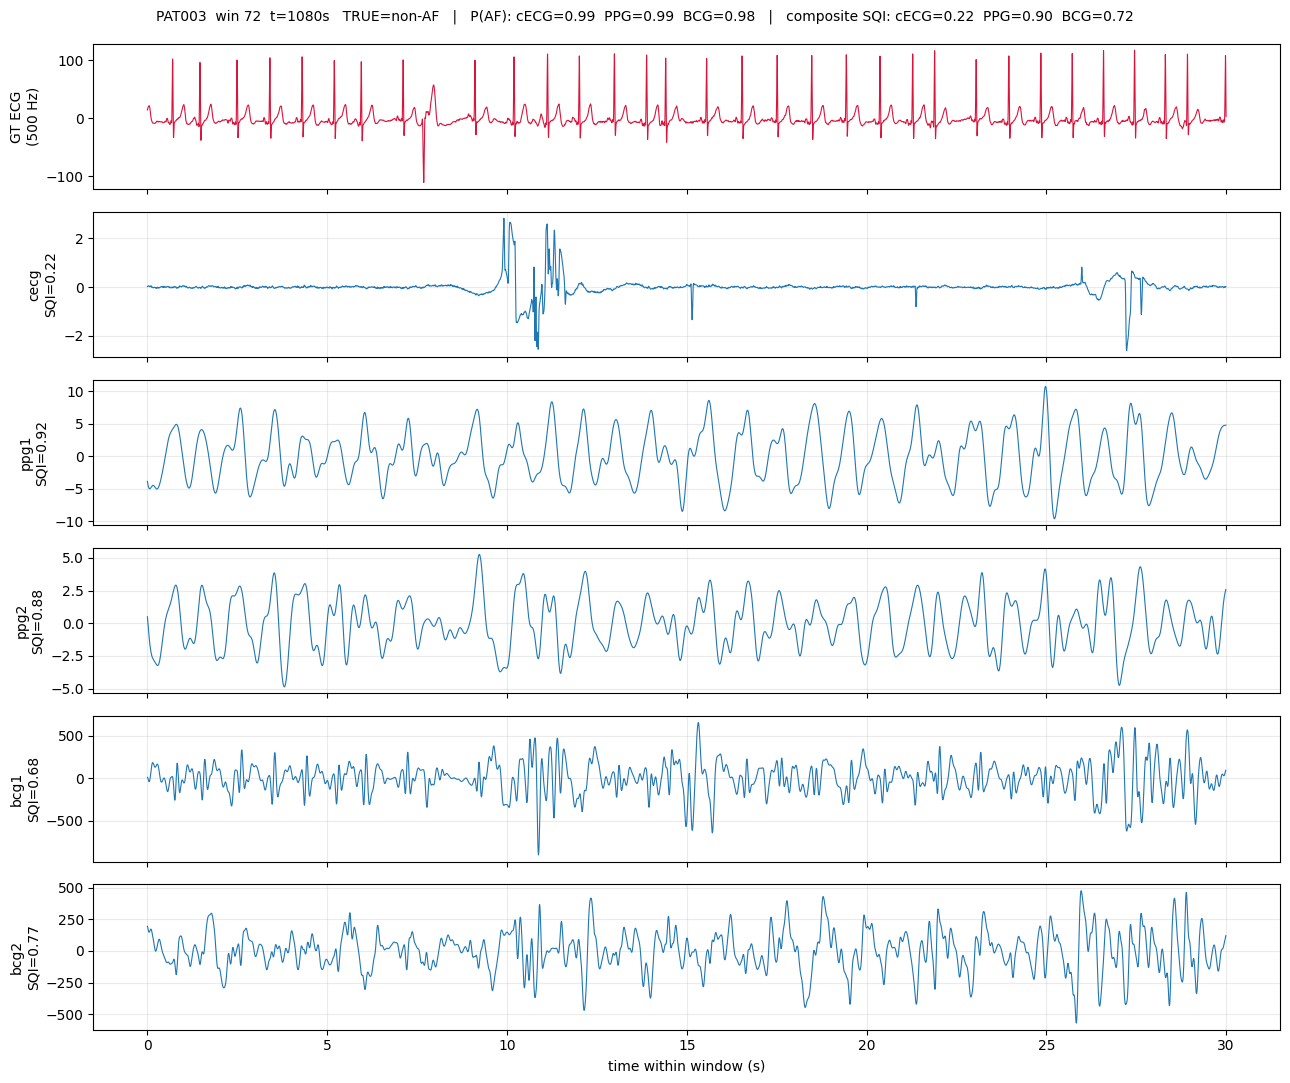

In [3]:
def _load_patient(pid):
    pat = PatientSignals(os.path.join(DATA_ROOT, pid))
    pat.filter_all(fs=FS); pat.offset_correction(fs=FS)
    return pat

def _synth_window(row):
    """Placeholder waveforms so the layout renders without real data."""
    rng = np.random.default_rng(int(row.name)); t = np.arange(WIN)/FS
    q = COMP[row.name]
    def chan(qual, freq, noisy):
        clean = np.sin(2*np.pi*freq*t)
        return (qual*clean + (1-qual)*rng.standard_normal(WIN)*(2 if noisy else 1))
    return {"cecg": chan(q[0], 1.2, True), "ppg1": chan(q[1], 1.1, False), "ppg2": chan(q[1], 1.1, False),
            "bcg1": chan(q[2], 1.1, False), "bcg2": chan(q[2], 1.1, False)}, np.sin(2*np.pi*1.2*np.arange(WINDOW_SEC*GT_FS)/GT_FS)

def plot_window(pid=None, win_idx=None, row=None):
    if row is None:
        sel = lab.index[(lab.patient == pid) & (lab.win_idx == win_idx)]
        if len(sel) == 0: print("no such window"); return
        row = int(sel[0])
    r = lab.iloc[row]; start = int(round(r.t_start_s * FS))
    if not SYNTHETIC:
        pat = _load_patient(r.patient)
        chans = {s: getattr(pat, f"{s}_filt")[start:start+WIN] for s in SIGNALS}
        gt = pat.gt_ecg_filt
        g0, g1 = int(r.t_start_s*GT_FS), int((r.t_start_s+WINDOW_SEC)*GT_FS)
        gtw = gt[g0:g1] if gt is not None else None
    else:
        chans, gtw = _synth_window(r)
    t = np.arange(WIN)/FS
    fig, ax = plt.subplots(6, 1, figsize=(13, 11), sharex=True)
    if gtw is not None:
        ax[0].plot(np.arange(len(gtw))/GT_FS, gtw, color="crimson", lw=.8)
    ax[0].set_ylabel("GT ECG\n(500 Hz)")
    for k, s in enumerate(SIGNALS, start=1):
        w = np.asarray(chans[s], float)
        ax[k].plot(t, w, lw=.8)
        comp = lab.iloc[row].get(f"sqi_{s}_composite", np.nan)
        ax[k].set_ylabel(f"{s}\nSQI={comp:.2f}" if np.isfinite(comp) else s)
        ax[k].grid(alpha=.25)
    ax[-1].set_xlabel("time within window (s)")
    title = (f"{r.patient}  win {int(r.win_idx)}  t={r.t_start_s:.0f}s   TRUE={'AF' if y[row]==1 else 'non-AF'}"
             f"   |   P(AF): cECG={P[row,0]:.2f}  PPG={P[row,1]:.2f}  BCG={P[row,2]:.2f}"
             f"   |   composite SQI: cECG={COMP[row,0]:.2f}  PPG={COMP[row,1]:.2f}  BCG={COMP[row,2]:.2f}")
    fig.suptitle(title, fontsize=10); plt.tight_layout(rect=[0,0,1,0.99]); plt.show()

if SYNTHETIC: print("(synthetic placeholder waveforms — point Section 1 at real data for true signals)")
if len(cand_rows):
    plot_window(row=cand_rows[0])
else:
    print("No window matched cECG-bad AND all-experts-wrong; loosen BAD_Q or the 'wrong' rule.")


## 4 · The case worth hunting: clean BCG, still wrong

These are the windows behind the 0.554 result — cECG bad (artifact), but BCG's SQI is *high* and its expert
is still wrong. If the BCG trace here looks like a clean, regular heartbeat yet the truth is AF (or vice
versa), that is direct visual evidence the limitation is in the **BCG features/expert**, not the signal or
the quality index. Step through a few with the arrow of your eye, not just the metric.

23 'cECG-bad, BCG-clean, all-wrong' windows.
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00


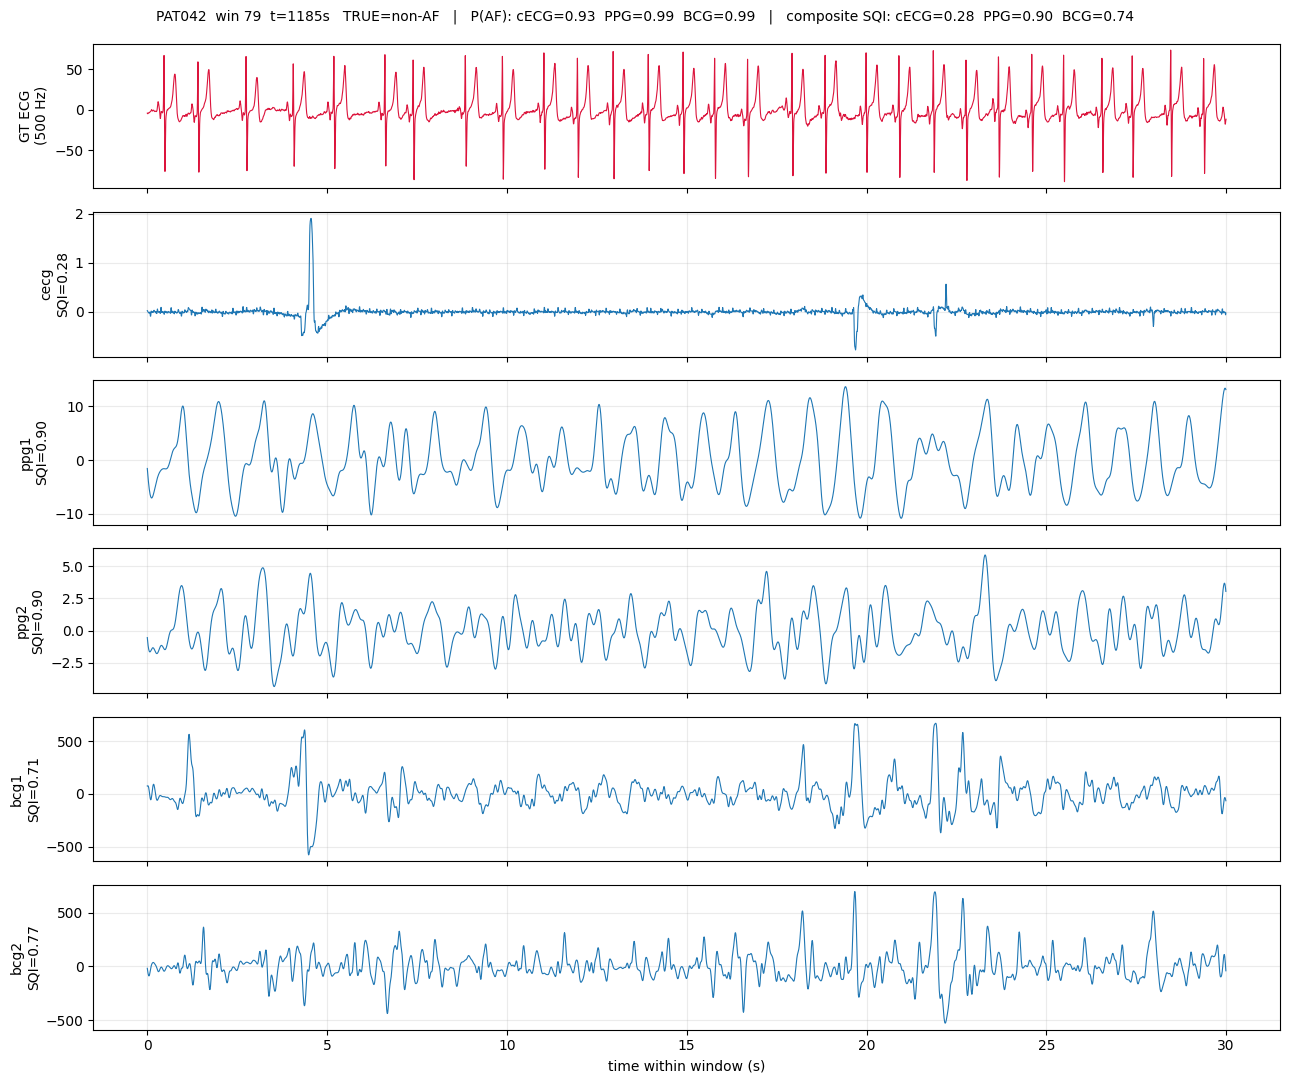

Tip: loop the rest with  for r in bcg_clean_wrong[:5]: plot_window(row=r)


In [6]:
bcg_clean_wrong = [r for r in cand_rows if COMP[r, 2] >= np.quantile(COMP[:, 2], 0.5)]
print(f"{len(bcg_clean_wrong)} 'cECG-bad, BCG-clean, all-wrong' windows.")
if bcg_clean_wrong:
    plot_window(row=bcg_clean_wrong[1])
    print("Tip: loop the rest with  for r in bcg_clean_wrong[:5]: plot_window(row=r)")
else:
    print("None found at this BAD_Q / threshold — relax the rule to inspect near-misses.")


## 5 · Compare against a clean, correct window (your eye needs a reference)

Hard to judge "bad" without "good." This plots a window where all experts are right and cECG quality is
high — your visual baseline for what an uncorrupted trace looks like on this hardware.

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 182  final_offset = 81
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg


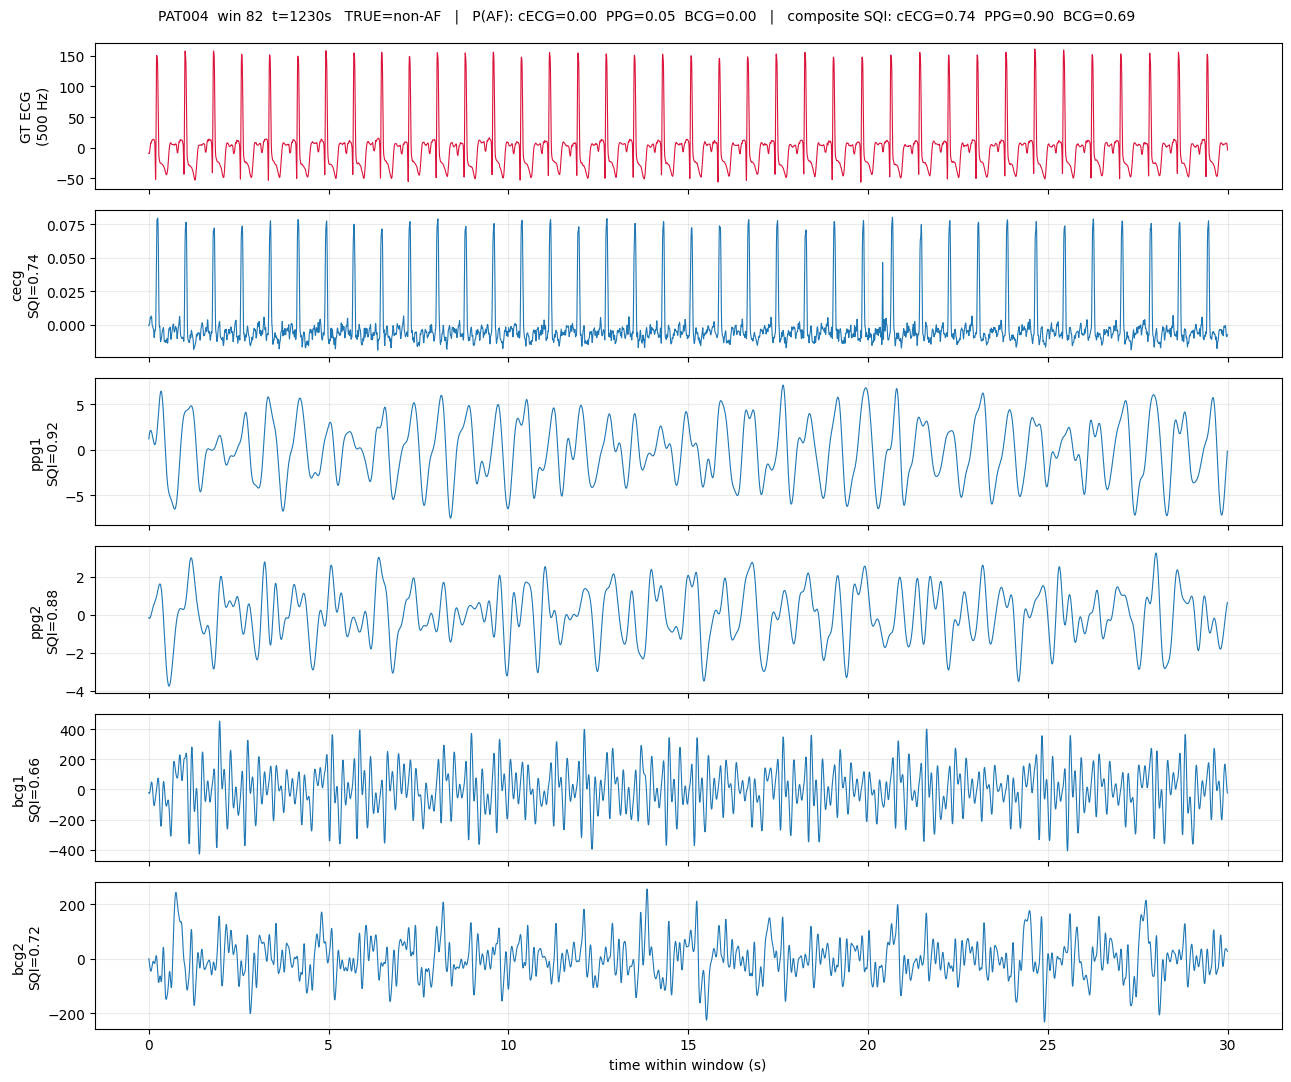

In [5]:
clean_ok = (COMP[:, 0] >= np.quantile(COMP[:, 0], 0.9)) & (((P >= 0.5).astype(int) == y[:, None]).all(1))
clean_rows = np.where(clean_ok)[0]
if len(clean_rows):
    plot_window(row=int(clean_rows[0]))
else:
    print("No high-quality all-correct window found; relax the quantile.")


In [7]:
for j, m in enumerate(MODALITIES):
    sub = COMP[:, 0] <= np.quantile(COMP[:, 0], 0.10)   # bad-cECG windows
    if len(np.unique(y[sub])) == 2:
        print(m, "AUC on bad-cECG:", round(roc_auc_score(y[sub], P[sub, j]), 3))

cecg AUC on bad-cECG: 0.614
ppg AUC on bad-cECG: 0.66
bcg AUC on bad-cECG: 0.623
